# Лабораторная работа №3

Студент: Рязанов Демид

Группа: Р3322

ИСУ: 367522

In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import time

online_retail = fetch_ucirepo(id=352)
data = online_retail.data.original

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]
data = data[data['Quantity'] > 0]
data = data.dropna(subset=['CustomerID'])

In [95]:
transactions_all = data.groupby('InvoiceNo')['StockCode'].apply(set).tolist()

split_idx = round(len(transactions_all) * 0.8)
np.random.seed(52)
np.random.shuffle(transactions_all)

transactions, transactions_tests = transactions_all[:split_idx], transactions_all[split_idx:]
all_items = sorted(set(data['StockCode'].unique()))

In [96]:
def apriori(transactions, min_support):
  def generate_candidates(itemsets, n_items):
    candidates = set()
    n = len(itemsets)
    for i in range(n):
      for j in range(i+1, n):
        set1 = itemsets[i]
        set2 = itemsets[j]
        union = set1.union(set2)
        if len(union) == n_items:
          candidates.add(union)

    candidates = list(candidates)
    pure_candidates = []

    for cand in candidates:
      subsets = [cand - {elem} for elem in cand]
      if all(sub in itemsets for sub in subsets):
        pure_candidates.append(cand)

    return pure_candidates

  n_transactions = len(transactions)
  frequent_itemsets = {}
  support_dict = {}

  count_items = {}
  for t in transactions:
    for i in t:
      count_items[i] = count_items.get(i, 0) + 1

  freq = []
  for item, count in count_items.items():
    support = count / n_transactions
    if support >= min_support:
      itemset = frozenset([item])
      support_dict[itemset] = support
      freq.append((itemset, support))
  frequent_itemsets[1] = freq

  c = 2
  while True:
    freq = []
    count_items = {}
    prev_itemsets = [itemset for itemset, _ in frequent_itemsets[c-1]]
    candidates = generate_candidates(prev_itemsets, c)

    for t in transactions:
      for cand in candidates:
        if cand.issubset(t):
          count_items[cand] = count_items.get(cand, 0) + 1

    for item, count in count_items.items():
      support = count / n_transactions
      if support >= min_support:
        itemset = item
        support_dict[itemset] = support
        freq.append((itemset, support))

    if len(freq) <= 0:
      break

    frequent_itemsets[c] = freq
    c += 1

  return frequent_itemsets, support_dict

In [97]:
def fpgrowth(transactions, min_support):
  class Node:
    def __init__(self, item, count, parent):
      self.item = item
      self.count = count
      self.parent = parent
      self.children = {}

  def build_tree(transactions, min_abs):
    counts = {}
    for t in transactions:
      for item in t:
        counts[item] = counts.get(item, 0) + 1

    freq_items = {item: cnt for item, cnt in counts.items() if cnt >= min_abs}
    if not freq_items:
      return None, None

    sorted_items = sorted(freq_items.items(), key=lambda x: (-x[1], x[0]))
    order = [item for item, _ in sorted_items]

    header = {item: [[], cnt] for item, cnt in sorted_items}

    root = Node(None, 0, None)

    def insert(transaction, node):
      if not transaction:
        return
      first = transaction[0]
      rest = transaction[1:]
      if first in node.children:
        child = node.children[first]
        child.count += 1
      else:
        child = Node(first, 1, node)
        node.children[first] = child
        header[first][0].append(child)
      insert(rest, child)

    for t in transactions:
      filtered = [item for item in t if item in freq_items]
      filtered.sort(key=lambda x: order.index(x))
      if filtered:
        insert(filtered, root)

    return root, header

  def mine_tree(header, min_abs, prefix, result):
    for item, (nodes, support) in sorted(header.items(), key=lambda x: x[1][1]):
      new_prefix = prefix + [item]
      result.append((frozenset(new_prefix), support))

      patterns = []
      for node in nodes:
        path = []
        p = node.parent
        while p and p.item is not None:
          path.append(p.item)
          p = p.parent
        if path:
          patterns.append((path[::-1], node.count))

      cond_trans = []
      for path, cnt in patterns:
        cond_trans.extend([path] * cnt)

      if cond_trans:
        _, cond_header = build_tree(cond_trans, min_abs)
        if cond_header:
          mine_tree(cond_header, min_abs, new_prefix, result)


  n_transactions = len(transactions)
  min_count = min_support * n_transactions
  root, header = build_tree(transactions, min_count)
  if header is None:
    return {}, {}

  itemsets_counts = []
  mine_tree(header, min_count, [], itemsets_counts)

  frequent_itemsets = {}
  support_dict = {}
  for itemset, sup_abs in itemsets_counts:
    sup_rel = sup_abs / n_transactions
    support_dict[itemset] = sup_rel
    size = len(itemset)
    frequent_itemsets.setdefault(size, []).append((itemset, sup_rel))

  return frequent_itemsets, support_dict

In [98]:
import time

min_support = 0.02

apr_start_time = time.time()
apr_freq_itemsets, apr_supp_dict = apriori(transactions, min_support)
apr_time = time.time() - apr_start_time

print(f'Время Apriori {apr_time}')

fpg_start_time = time.time()
fpg_freq_itemsets, fpg_supp_dict = fpgrowth(transactions, min_support)
fpg_time = time.time() - fpg_start_time

print(f'Время Fpgrowth {fpg_time}')

Время Apriori 57.53698968887329
Время Fpgrowth 1.1608521938323975


In [99]:
from itertools import combinations

def generate_rules_from_dict(support_dict, min_confidence):
  rules = []
  for itemset, support in support_dict.items():
    if len(itemset) < 2:
      continue
    items = list(itemset)

    for i in range(1, len(items)):
      for ante in combinations(items, i):
        antecedent = frozenset(ante)
        consequent = itemset - antecedent
        if not consequent:
          continue

        support_ante = support_dict.get(antecedent, 0)
        if support_ante == 0:
          continue

        confidence = support / support_ante
        if confidence >= min_confidence:
          rules.append((antecedent, consequent, confidence))
  return rules

def get_descr_from_item_id(id):
  return data[data['StockCode'] == id].iloc[0]['Description']

def plot_rules(rules):
  rules_sorted = sorted(rules, key=lambda x: x[2], reverse=True)

  labels = []
  for ante, cons, _ in rules_sorted:
    ante_items = list(ante)[:2]
    ante_items = [get_descr_from_item_id(a) for a in ante_items]
    cons_items = list(cons)[:1]
    cons_items = [get_descr_from_item_id(c) for c in cons_items]
    label = f"{','.join(ante_items)} -> {','.join(cons_items)}"
    labels.append(label)

  values = [conf for _, _, conf in rules_sorted]

  plt.figure(figsize=(12, 6))
  plt.bar(range(len(labels)), values, tick_label=labels)
  plt.xlabel('Правило')
  plt.ylabel('Достоверность (Confidence)')
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

/tmp/ipykernel_678/906487806.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


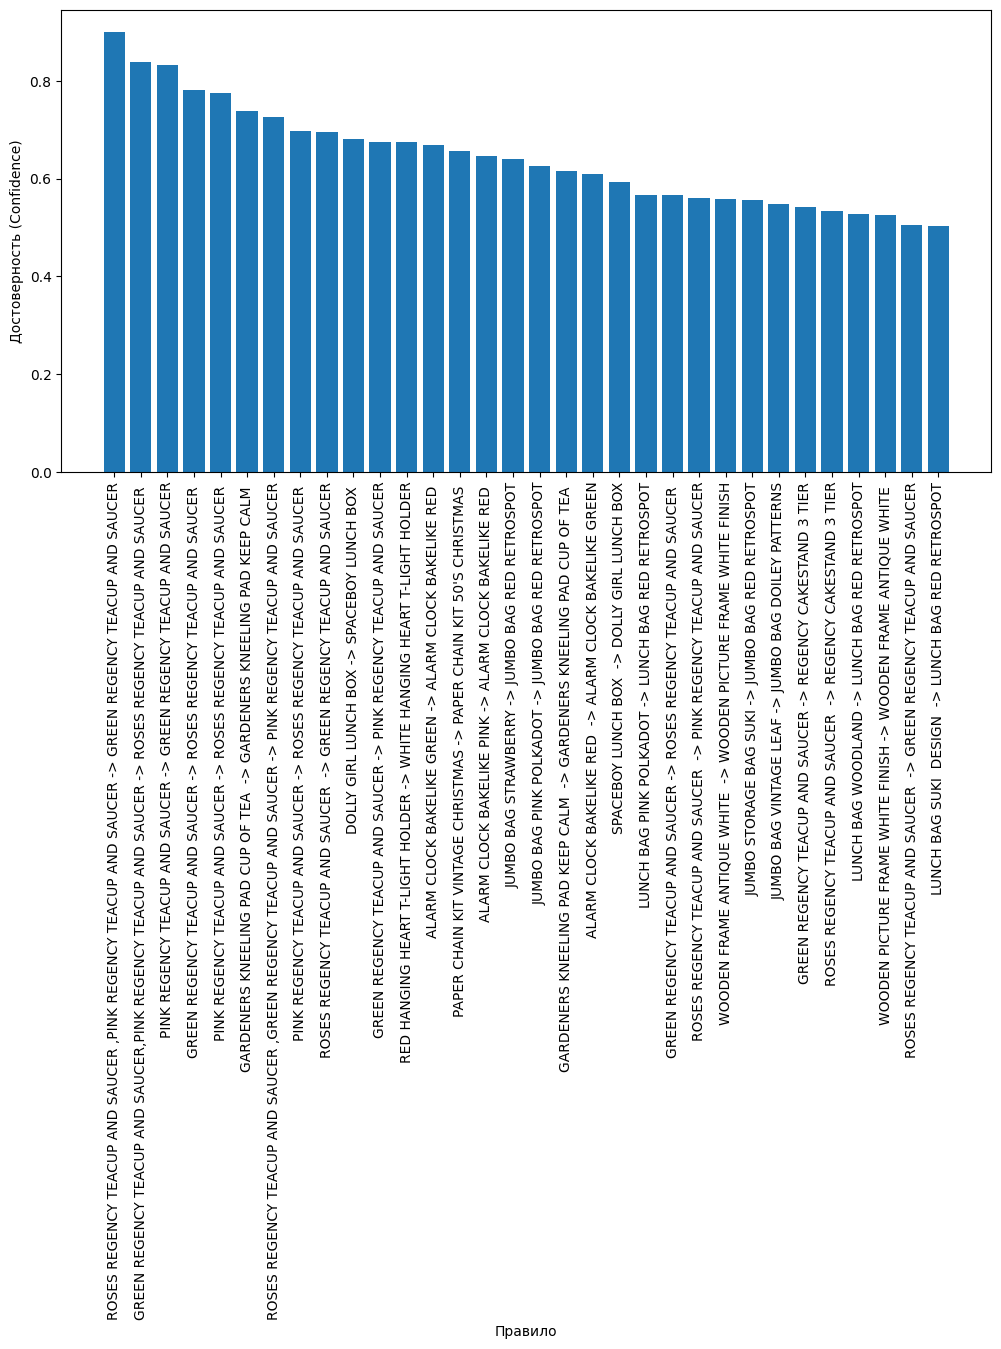

/tmp/ipykernel_678/906487806.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


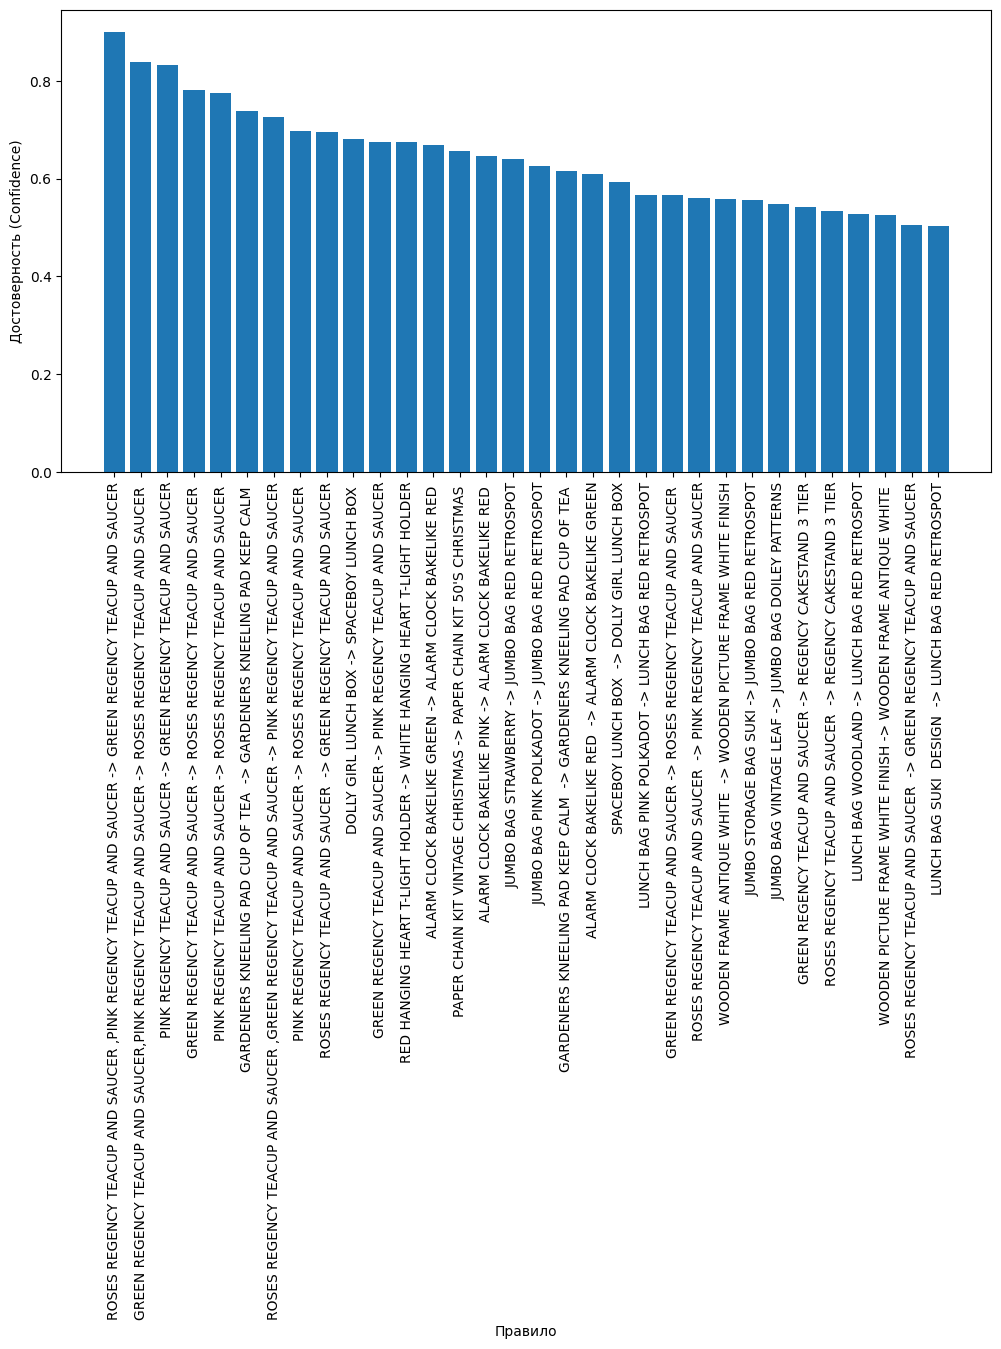

In [100]:
min_confidence = 0.5

apr_rules = generate_rules_from_dict(apr_supp_dict, min_confidence)
fpg_rules = generate_rules_from_dict(fpg_supp_dict, min_confidence)

plot_rules(apr_rules)
plot_rules(fpg_rules)

In [130]:
def recommend(basket, rules, top_n=5):
  if not isinstance(basket, set):
    basket = set(basket)
  scores = {}
  for ante, cons, conf in rules:
    if ante.issubset(basket) and cons not in basket:
      if cons not in scores or conf > scores[cons]:
        scores[cons] = conf
  sorted_rec = sorted(scores.items(), key=lambda x: x[1], reverse=True)
  sorted_rec = sorted_rec[:top_n]
  return sorted_rec

sample_basket = list(transactions[122])
removed_item = sample_basket.pop()

apr_recs = recommend(sample_basket, apr_rules, top_n=5)
fpg_recs = recommend(sample_basket, fpg_rules, top_n=5)

In [131]:
get_descr_from_item_id(removed_item)

'TRAVEL CARD WALLET PANTRY'

In [132]:
for rec, conf in apr_recs:
  s = [get_descr_from_item_id(r) for r in list(rec)]
  print(s, conf)

['JUMBO BAG DOILEY PATTERNS'] 0.5486443381180223


In [133]:
for rec, conf in fpg_recs:
  s = [get_descr_from_item_id(r) for r in list(rec)]
  print(s, conf)

['JUMBO BAG DOILEY PATTERNS'] 0.5486443381180223


In [108]:
a_good_rec = 0
f_good_rec = 0
n = 5
for i in range(len(transactions_tests)):
  sample_basket = list(transactions_tests[i])
  removed_item = sample_basket.pop()

  a_recs = recommend(sample_basket, apr_rules, top_n=n)
  f_recs = recommend(sample_basket, fpg_rules, top_n=n)

  a_recs = [rec for rec, conf in a_recs]
  f_recs = [rec for rec, conf in f_recs]

  for r in a_recs:
    if removed_item in r:
      a_good_rec += 1

  for r in f_recs:
    if removed_item in r:
      f_good_rec += 1

print(f"Apriori good rec: {a_good_rec / len(transactions_tests) :.5f}")
print(f"FPGrowth good rec: {f_good_rec / len(transactions_tests) :.5f}")
print(f"Random rec: {n / len(all_items) :.5f}")

rec_score = a_good_rec / len(transactions_tests)
rand_score = n / len(all_items)

print(f"Алгоритмы лучше рандома в {rec_score / rand_score :.2f} раз")

Apriori good rec: 0.03615
FPGrowth good rec: 0.03615
Random rec: 0.00136
Алгоритмы лучше рандома в 26.50 раз


UPD: после сдачи лабы (Вы не просили, но) поигрался и добавил -
1) разделение выборки транзакций на обучающую и тестовую
2) оценил % хороших рекомендаций (попаданий в удаленный из корзины объект) от моделей, сравнил его с вероятностью попадания при рандомной рекомендации